In [1]:
import numpy as np 
from matplotlib import pyplot as plt
plt.rcParams.update({'font.size': 16})
import pandas as pd
import random as rand

In [3]:
#soil moisture loss function
def loss_func (ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss):
    if (ss <= sh):
        losses = 0
    elif ((ss > sh) and (ss <= sw)):
        losses = (ET_w/(n*Zr))*((ss-sh)/(sw-sh))
    elif ((ss > sw) and (ss <= s1)):
        losses = (ET_w + (ET_max - ET_w)*((ss-sw)/(s1-sw)))/(n*Zr)
    elif ((ss > s1) and (ss <= sfc)):
        losses = (ET_max/(n*Zr))
    else:
        losses = (ET_max/(n*Zr))+(1/(n*Zr))*(Ks/(np.exp(beta*(1-sfc))-1) * ((np.exp(beta*(ss-sfc))) - 1 ))
        
    return losses

# Soil Properties
def soil(x):
    if x == "loamy sand":
        n = 0.42 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [mm/day] at wilting point
        phis = -0.17*10**-3 #(MPa)
        b = 4.38
        sfc = 0.52 # soil moisture at field capacity
        sw = 0.11 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.31 # soil moisture at onset of plant stress
        beta = 12.7 # soil term to calculate K(s) decay as part of leakage term
        Ks = 100 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)        
        nn = 0.1362 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "sand":
        n = 0.35 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -0.34*10**-3 #(MPa)
        b = 4.05
        sfc = 0.35 # soil moisture at field capacity
        sw = 0.11 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.33 # soil moisture at onset of plant stress
        beta = 12.1 # soil term to calculate K(s) decay as part of leakage term
        Ks = 200 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)        
        nn = 0.154 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    elif x == "loam":
        n = 0.45 # soil porosity [-],
        Zr = 30 # Depth of the rooting zone [cm]
        ET_max = 0.45 # maximum value of ET [cm/day]
        ET_w = 0.01 #  value of ET [cm/day] at wilting point
        phis = -1.43*10**-3 #(MPa)
        b = 5.39
        sfc = 0.65 # soil moisture at field capacity
        sw = 0.24 # wilting point
        sh = (phis/-10000)**(1/b) # soil moisture at hygroscopic point
        swh = (phis/-100)**(1/b)
        s1 = 0.57 # soil moisture at onset of plant stress
        beta = 13.8 # soil term to calculate K(s) decay as part of leakage term
        Ks= 20 # saturated hydraulic conductivity of the soil [K(ss=1)] (cm/day)
        nn = 0.18 # Normalization constant, so f[s] max =1
        km = 0.03    #(*microbial deposition rate*)
        hh = 0.92     #(*Influence of temperature on bacteria metabolism, Ehhalt and Roher(2011)*)
        sopt = (phis/-0.3)**(1/b)
        beta1 = 0.4
        beta2 = beta1*((1-sopt)/(sopt-swh))
        beta22 = beta1*((1-sopt)/(sopt-sw))
        
    else:
        pass
    return n, Zr, ET_max, ET_w, sfc, sw, sh,swh, s1, beta, Ks, nn, km, hh, beta1,sopt, beta2, beta22

# Response of biotic H2 consuming bacteria to soil moisture 
def fh(ss):
    if ss <= swh:
        fs = 0
    else:
        fs = (((ss-swh)**beta1)*((1-ss)**beta2))/(((sopt-swh)**beta1)*((1-sopt)**beta2))
    return fs

def fhm(ss):
    if ss <= swh:
        fs = (0.01/swh)*ss
    #elif swh < ss <= dm:
        #fs = 1/100
    else:
        fs = (((ss-swh)**beta1)*((1-ss)**beta2))/(((sopt-swh)**beta1)*((1-sopt)**beta2))
    return fs

# Response of Organic Carbon consuming bacteria to soil moisture
def fc(ss):
    if ss <= sw:
        fs=0
    elif sw < ss <= sfc:
        fs = (ss - sw)/(sfc - sw)
    else:
        fs = sfc/ss
    return fs
#total conductance of the soil and diffusive barrier
def gt(ss):
    gt = ((n**2)*((1-ss)**(2+3/4.38))*(0.5**2)*0.756)/((n**2)*((1-ss)**(2+3/4.38)) +(0.5**2))
    return gt

# H2 Diffusive flux
def ff(ss,H):
    ff = gt(ss)*(Ha-H)
    return ff

# h2 biological sink
def bd(s, Cs, Bh):
    bd = hh*khh*fh(s)*Cs*Bh
    return bd

# Velocity that indicates the potential bological sink along depth Zr
def vbd(s, Cs, Bh):
    vbd = Zr*bd(s, Cs, Bh)
    return vbd
# Quasi steady approximation of H2 conecntration in the soil
def hyd(s, Cs, Bh):
    hyd = Ha/(1 + (vbd(s, Cs, Bh)/gt(s)))
    return hyd

# Considering Dormancy
def bdm(s, Cs, Bh, dm):
    bd = hh*khh*fhm(s)*Cs*Bh
    return bd

def vbdm(s, Cs, Bh, dm):
    vbd = Zr*bdm(s, Cs, Bh, dm)
    return vbd

def hydm(s, Cs, Bh, dm):
    hyd = Ha/(1 + (vbdm(s, Cs, Bh, dm)/gt(s)))
    return hyd


def rainfall(y):
    alpha_p = 1.5 # average precipitation per event[cm]
    rainfall_ = np.zeros(int(length/dt))
    for i in range(0, int(length/dt)):
        r = np.random.default_rng().exponential(y)
        if r < y*dt:
            rainfall_[i] = np.random.default_rng().exponential(alpha_p/(n*Zr))
        else:
            rainfall_[i] = 0
    return rainfall_

In [4]:
# Generate parameters for loamy sand
n, Zr, ET_max, ET_w, sfc, sw, sh,swh, s1, beta, Ks, nn, km, hh, beta1,sopt, beta2, beta22 = soil("loamy sand")

In [12]:
length = 73000 # simulation time (days)
s0 = 0.5 # Soil moisture at the beginnig of the simulation [-]
Ha = 530  #(*Atmospheric concentration of hydrogen* ppb)
dt = 0.001 # time interval (days)
time = np.linspace(0,length-dt,int(length/dt))

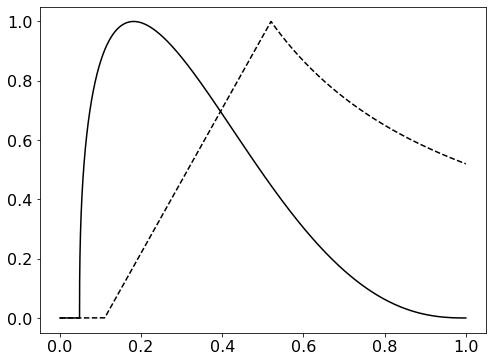

In [29]:
# Appendix figures

plt.figure(figsize=(8,6))
plt.plot(s, B1, color="black", linestyle='--')
plt.plot(s, fhhh1, color="black");

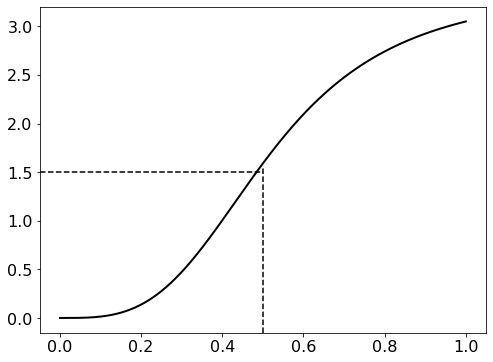

In [32]:
plt.figure(figsize=(8,6))
plt.plot(s, A1, color="black", linewidth=2)
plt.axvline(0.5,ymax=0.51, color="k", linestyle='--')
plt.axhline(1.5,xmax=0.5, color="k", linestyle='--')

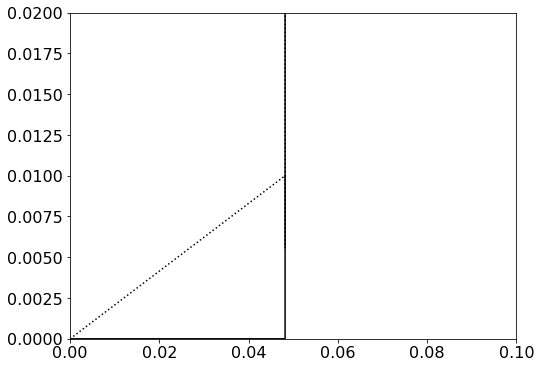

In [14]:
plt.figure(figsize=(8,6))
plt.plot(s, fhhh, color="k", linestyle="dotted")
plt.plot(s, fhhh1, color="k");
plt.ylim([0,0.02])
plt.xlim([0,0.1]);

In [42]:
y = 0.01
rain_vec = rainfall(y)
#plt.bar(time, rain_vec);

In [5]:
# Space for S_dorm
dorm = np.linspace(swh, sw, 5)
dorm

array([0.04816714, 0.06362536, 0.07908357, 0.09454179, 0.11      ])

In [8]:
# Soil moisture drydown 
ss_dry = np.zeros(int(dry/dt))
ss_dry[0] = 1
def drydown(x):
    ss_vec = x.copy()
    for i in range(1, int(dry/dt)):
        loss =  loss_func(ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss_vec[i-1])
        ss_vec[i] = ss_vec[i-1] - dt*loss
            
    return ss_vec
    
# Soil moisture Equation solution
def run_ss(x):
    ss_vec = x.copy()
    for i in range(1, int(length/dt)):
        loss =  loss_func(ET_max,ET_w,n,Zr,sh,sw,s1,sfc,ss_vec[i-1])
        ss_vec[i] = ss_vec[i-1] + rain_vec[i] - dt*loss
            
    return ss_vec

In [13]:
# Parameters
ADD_max = 3.2 #g/m3/day
ADD_min = 0 #g/m3/day
khh = 3.2*10**-4 # Potential decomposition rate for hydrogen
kcc = 1.8*10**-3 # Potential decomposition rate for carbon
mc = 0.005 # Mortality rate for carbon microbes
mh = 0.005 # Mortality rate for Hydrogen microbes
rc = 0.6 # Respiration rate for Carbon microbes
rh = 0.6 # Respiration rate for Hydrogen microbes
q = 12*0.0072 # carbon to hydrogen ratio [C/H]

def ADD(s):
    ADD = ADD_max + (ADD_min - ADD_max)/(1 + (s/sfc)**3.31)
    return ADD

# Dormancy included as dm
def substrate_sol(i, dm):
    # Dormancy condition
    if ss[i] <= dm:
        eta = 0 # defind as chi in paper
        mh = 0.00005 # Mortality rate for Hydrogen microbes
    else:
        eta = 1
        mh = 0.005 # Mortality rate for Hydrogen microbes
    kc = kcc*hh*fc(ss[i-1])
    kh = khh*hh*fhm(ss[i-1])
    DEC_c = kc*Cs[i-1]*Bc[i-1]
    DEC_h = eta*q*kh*Cs[i-1]*Bh[i-1]*H[i-1]*n*(1-ss[i-1])
    BD_c = mc*Bc[i-1]
    BD_h = mh*Bh[i-1]
    cs = Cs[i-1] + dt*(ADd - DEC_c - DEC_h + BD_c + BD_h)
    return cs

def Microbe_c(i):
    kc = kcc*hh*fc(ss[i-1])
    DEC_c = kc*Cs[i-1]*Bc[i-1]
    BD_c = mc*Bc[i-1]
    bc = Bc[i-1] + dt*((1-rc)*DEC_c - BD_c)
    return bc

def Microbe_h(i, dm):
    # Dormancy condition
    if ss[i] <= dm:
        eta = 0
        mh = 0.00005 # Mortality rate for Hydrogen microbes
    else:
        eta = 1
        mh = 0.005 # Mortality rate for Hydrogen microbes
    kh = khh*hh*fhm(ss[i-1])
    DEC_h = eta*q*kh*Cs[i-1]*Bh[i-1]*H[i-1]*n*(1-ss[i-1])
    BD_h = mh*Bh[i-1]
    bh = Bh[i-1] + dt*((1-rh)*DEC_h - BD_h)
    return bh

def run_hyd(i, dm):
    flux = ff(ss[i-1], H[i-1])
    b_d = bdm(ss[i-1], Cs[i-1], Bh[i-1], dm)*H[i-1]*Zr
    air = 1 - ss[i-1]
    H_vec = H[i-1] + ((flux - b_d))/(n*Zr*air) + H[i-1]*(ss[i] - ss[i-1])/air
    if H_vec > Ha:
        H_vec = Ha
    return H_vec

Cs = np.zeros(int(length/dt))
Cs[0] = 12
Bc = np.zeros(int(length/dt))
Bc[0] = 2.5
Bh = np.zeros(int(length/dt))
Bh[0] = 1
ss_vec = np.zeros(int(length/dt))
ss_vec[0] = s0

hyd_vec = np.zeros(int(length/dt)) #Quasi steady approximation
H = np.zeros(int(length/dt))

In [45]:
# No dormancy conditions

def substrate_sol1(i):
    kc = kcc*hh*fc(ss[i-1])
    kh = khh*hh*fh(ss[i-1])
    DEC_c = kc*Cs1[i-1]*Bc1[i-1]
    DEC_h = q*kh*Cs1[i-1]*Bh1[i-1]*H1[i-1]*n*(1-ss[i-1])
    BD_c = mc*Bc1[i-1]
    BD_h = mh*Bh1[i-1]
    cs = Cs1[i-1] + dt*(ADd - DEC_c - DEC_h + BD_c + BD_h)
    return cs

def Microbe_c1(i):
    kc = kcc*hh*fc(ss[i-1])
    DEC_c = kc*Cs1[i-1]*Bc1[i-1]
    BD_c = mc*Bc1[i-1]
    bc = Bc1[i-1] + dt*((1-rc)*DEC_c - BD_c)
    return bc

def Microbe_h1(i):
    kh = khh*hh*fh(ss[i-1])
    DEC_h = q*kh*Cs1[i-1]*Bh1[i-1]*H1[i-1]*n*(1-ss[i-1])
    BD_h = mh*Bh1[i-1]
    bh = Bh1[i-1] + dt*((1-rh)*DEC_h - BD_h)
    return bh

def run_hyd1(i):
    flux = ff(ss[i-1], H1[i-1])
    b_d = hh*khh*fh(ss[i-1])*Cs1[i-1]*Bh1[i-1]*H1[i-1]*Zr
    air = 1 - ss[i-1]
    H_vec = H1[i-1] + (flux - b_d)/(n*Zr*air) + H1[i-1]*(ss[i] - ss[i-1])/air
    if H_vec > 530:
        H_vec = 530
    return H_vec
def hyd1(s, Cs, Bh):
    hyd = Ha/(1 + (hh*khh*fh(s)*Cs*Bh*Zr)/gt(s))
    return hyd

Cs1 = np.zeros(int(length/dt))
Cs1[0] = 12
Bc1 = np.zeros(int(length/dt))
Bc1[0] = 2.5
Bh1 = np.zeros(int(length/dt))
Bh1[0] = 1

hyd_vec1 = np.zeros(int(length/dt)) #Quasi steady approximation
hyd_vec1[0] = hyd1(s0, Cs1[0], Bh1[0])
H1 = np.zeros(int(length/dt))
H1[0] = hyd_vec1[0]

In [14]:
%%time
ss = run_ss(ss_vec)
ADd = ADD(np.mean(ss))

BH = pd.DataFrame(ss, columns=["ss"])
HH = pd.DataFrame(ss, columns=["ss"])

# Solution with dormancy
for j in range(len(dorm)):
    dm = round(dorm[j],3)
    hyd_vec[0] = hydm(s0, Cs[0], Bh[0], dm)
    H[0] = hyd_vec[0]
    for i in range(1, int(length/dt)):
        Bc[i] = Microbe_c(i)
        Cs[i] = substrate_sol(i, dm)
        Bh[i] = Microbe_h(i, dm)
        H[i] = run_hyd(i, dm)
    BH[f"Bh_{dm}"] = Bh
    HH[f"H_{dm}"] = H

# Solution with no dormancy
for i in range(1, int(length/dt)):
    Bc1[i] = Microbe_c1(i)
    Cs1[i] = substrate_sol1(i)
    Bh1[i] = Microbe_h1(i)
    H1[i] = run_hyd1(i)
    hyd_vec1[i] = hyd1(ss[i], Cs1[i], Bh1[i])


CPU times: user 3min 16s, sys: 75.2 ms, total: 3min 16s
Wall time: 3min 17s


In [53]:
BH["Bh_0"] = Bh1
HH["H_0"] = H1

# Save data
BH.to_csv("BH+dorm200.csv")
HH.to_csv("HH+dorm200.csv")

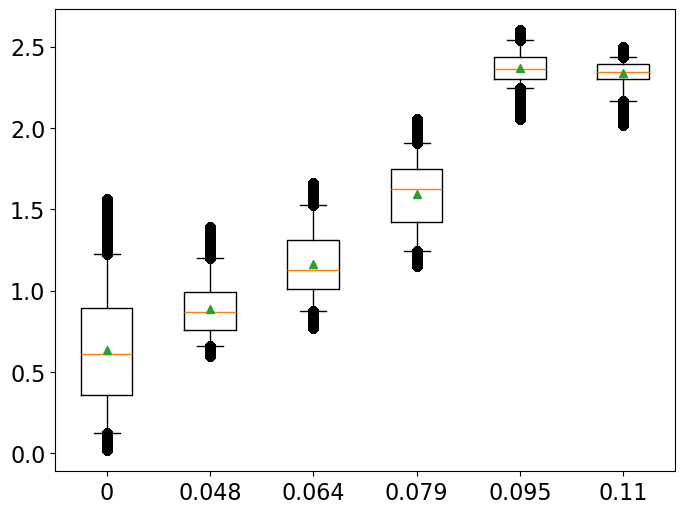

In [42]:
# Figure 8

skip = 5000000 # skip initial transient
length = 73000000

data = [
    BH["Bh_0"][skip:length],
    BH["Bh_0.048"][skip:length],
    BH["Bh_0.064"][skip:length],
    BH["Bh_0.079"][skip:length],
    BH["Bh_0.095"][skip:length],
    BH["Bh_0.11"][skip:length]
]

labels = ["0", "0.048", "0.064", "0.079", "0.095", "0.11"]

plt.figure(figsize=(8, 6))
plt.boxplot(
    data,
    whis=[5, 95],
    showfliers=True,
    showmeans=True,
    labels=labels
)
#plt.xlabel("Dormancy Rate")
#plt.ylabel("Biomass (Bh)")
#plt.xticks(rotation=60, ha="right")
#plt.tight_layout()
plt.show()

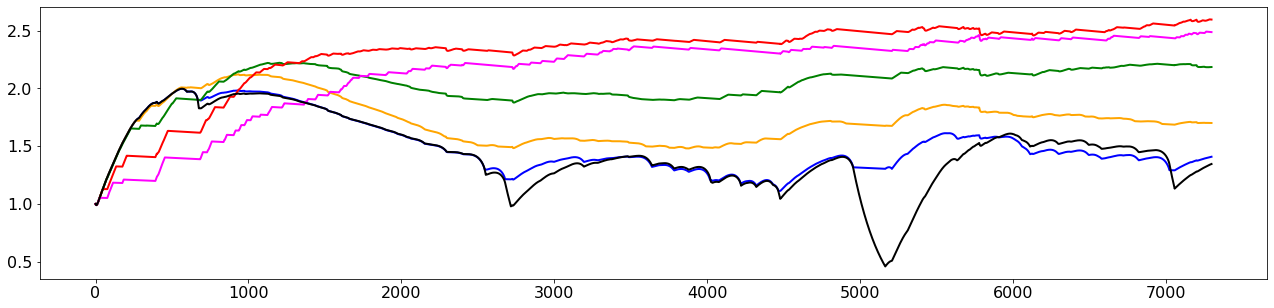

In [21]:
plt.figure(figsize=(22,5))
plt.plot(time, BH["Bh_0.048"], color="blue", linewidth=2)
plt.plot(time, BH["Bh_0.064"], color="orange", linewidth=2)
plt.plot(time,BH["Bh_0.079"], color="green", linewidth=2)
plt.plot(time,BH["Bh_0.095"], color="red", linewidth=2)
plt.plot(time,BH["Bh_0.11"], color="magenta", linewidth=2)
plt.plot(time, Bh1, color="k", linewidth=2)
#plt.ylabel(r'$B_H$ [gCm$^{-3}$]', fontsize=16);

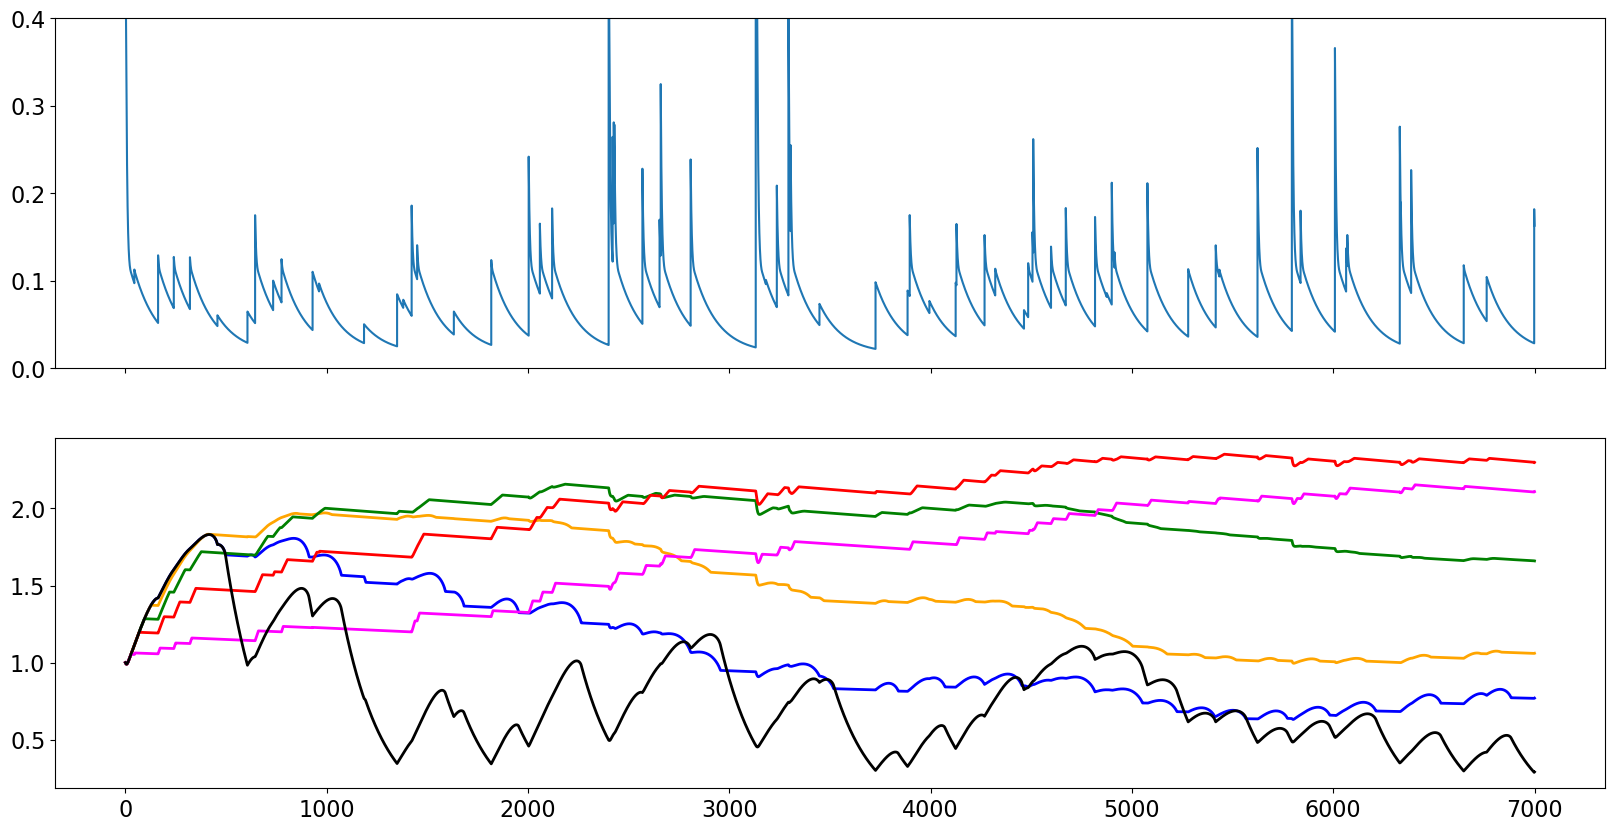

In [30]:
# Figure 7

fig, axs = plt.subplots(2, 1, figsize=(20,10), sharex=True)
axs[0].plot(time[: 7000000], ss[: 7000000])
axs[0].set_ylim([0,0.4])
axs[1].plot(time[: 7000000], BH["Bh_0.048"][: 7000000], color="blue", linewidth=2)
axs[1].plot(time[: 7000000], BH["Bh_0.064"][: 7000000], color="orange", linewidth=2)
axs[1].plot(time[: 7000000], BH["Bh_0.079"][: 7000000], color="green", linewidth=2)
axs[1].plot(time[: 7000000], BH["Bh_0.095"][: 7000000], color="red", linewidth=2)
axs[1].plot(time[: 7000000], BH["Bh_0.11"][: 7000000], color="magenta", linewidth=2)
axs[1].plot(time[: 7000000], BH["Bh_0"][: 7000000], color="k", linewidth=2);

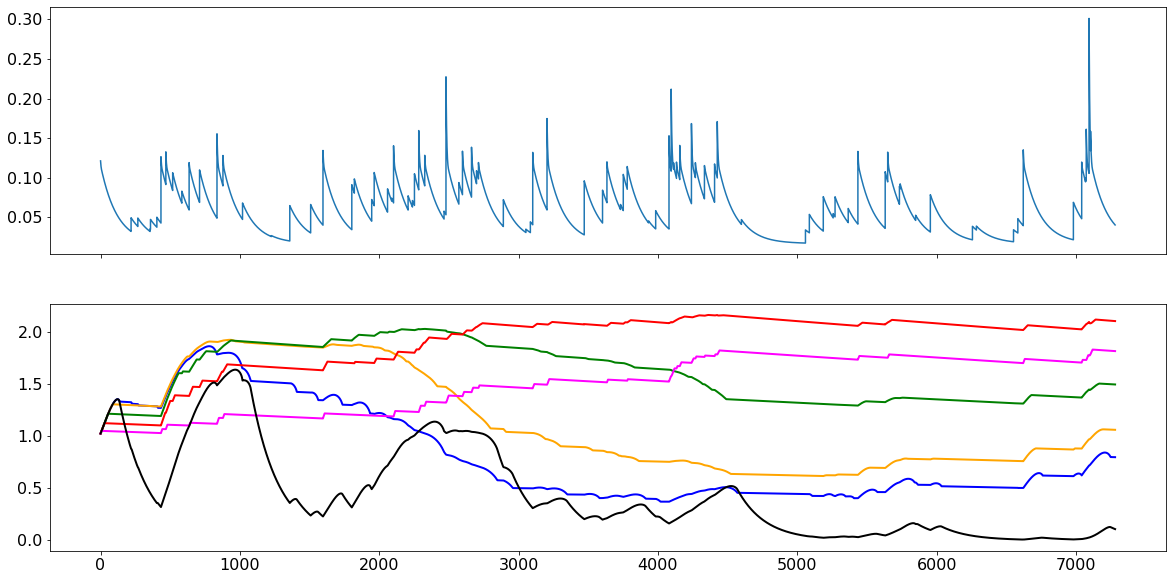

In [45]:
fig, axs = plt.subplots(2, 1, figsize=(20,10), sharex=True)
axs[0].plot(time[:-20000], BH["ss"][20000:])
axs[1].plot(time[:-20000], BH["Bh_0.048"][20000:], color="blue", linewidth=2)
axs[1].plot(time[:-20000], BH["Bh_0.064"][20000:], color="orange", linewidth=2)
axs[1].plot(time[:-20000], BH["Bh_0.079"][20000:], color="green", linewidth=2)
axs[1].plot(time[:-20000], BH["Bh_0.095"][20000:], color="red", linewidth=2)
axs[1].plot(time[:-20000], BH["Bh_0.11"][20000:], color="magenta", linewidth=2)
axs[1].plot(time[:-20000], BH["Bh_0"][20000:], color="k", linewidth=2);